# Собираем большой goldenset


In [ ]:
from datetime import datetime, timezone
import json
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from huggingface_hub import HfApi

old_df = pd.DataFrame(json.loads(Path("data/goldenset.json").read_text()))
valid_path = sorted(Path("../tasks").glob("mine_larger_goldenset_valid_*.json"))[-1]
valid_df = pd.DataFrame(json.loads(valid_path.read_text()))

hf = load_dataset("vsevolod-nv/aiconf-butterfly-detection-all")
hf_df = hf["train"].to_pandas() if "train" in hf else hf[list(hf.keys())[0]].to_pandas()

if "photo_url" in hf_df.columns:
    hf_df["image"] = hf_df["photo_url"]
if "taxon" in hf_df.columns and "entity" not in hf_df.columns:
    hf_df["entity"] = hf_df["taxon"]

old_df["photo_id"] = old_df["photo_id"].astype(str)
valid_df["photo_id"] = valid_df["photo_id"].astype(str)
hf_df["photo_id"] = hf_df["photo_id"].astype(str)


AttributeError: 'list' object has no attribute 'read_text'

In [ ]:
old_clean_df = old_df.loc[
    old_df["bbox"].notna() | old_df["entity"].ne("butterfly"),
    ["photo_id", "image", "entity", "bbox"],
].copy()

entity_map_df = hf_df[["photo_id", "entity"]].dropna().drop_duplicates("photo_id")
valid_df = valid_df.merge(entity_map_df.rename(columns={"entity": "source_entity"}), on="photo_id", how="left")

valid_clean_df = valid_df.loc[valid_df["is_valid"]].copy()
valid_clean_df["entity"] = valid_clean_df["source_entity"].where(~valid_clean_df["has_bbox"], "butterfly")
valid_clean_df["bbox"] = valid_clean_df["guides"].apply(
    lambda guides: None if not guides else {
        "shape": "rectangle",
        "left": float(guides[0]["left"]),
        "top": float(guides[0]["top"]),
        "width": float(guides[0]["width"]),
        "height": float(guides[0]["height"]),
    }
)
valid_clean_df = valid_clean_df[["photo_id", "image", "entity", "bbox"]].copy()

display(pd.DataFrame([
    {"source": "old goldenset", "rows": len(old_clean_df)},
    {"source": "validated mine-larger-goldenset", "rows": len(valid_clean_df)},
]))


,source,rows
0,old goldenset,137
1,validated mine-larger-goldenset,154


In [ ]:
negative_classes = ["bee", "beetle", "flower", "shrub"]

raw_negative_df = hf_df.loc[
    hf_df["entity"].isin(negative_classes),
    ["photo_id", "image", "entity"],
].copy()
raw_negative_df["bbox"] = None
raw_negative_df = raw_negative_df.drop_duplicates("photo_id").reset_index(drop=True)

merged_df = pd.concat([old_clean_df, valid_clean_df], ignore_index=True)
merged_df = merged_df.drop_duplicates("photo_id").reset_index(drop=True)

positive_df = merged_df.loc[
    merged_df["entity"].eq("butterfly") & merged_df["bbox"].notna(),
    ["photo_id", "image", "entity", "bbox"],
].copy()

negative_df = merged_df.loc[
    merged_df["entity"].isin(negative_classes) & merged_df["bbox"].isna(),
    ["photo_id", "image", "entity", "bbox"],
].copy()

raw_negative_df = raw_negative_df.loc[~raw_negative_df["photo_id"].isin(set(merged_df["photo_id"]))].copy()

base = len(positive_df) // len(negative_classes)
remainder = len(positive_df) % len(negative_classes)
target_by_class = {
    entity: base + (1 if i < remainder else 0)
    for i, entity in enumerate(negative_classes)
}

balanced_negative_parts = []
summary_rows = []
for entity in negative_classes:
    target = target_by_class[entity]
    current_part = negative_df.loc[negative_df["entity"].eq(entity)].copy()
    extra_needed = max(0, target - len(current_part))
    extra_part = raw_negative_df.loc[raw_negative_df["entity"].eq(entity)].head(extra_needed).copy()
    current_part = current_part if len(current_part) <= target else current_part.sample(n=target, random_state=42)
    part = pd.concat([current_part, extra_part], ignore_index=True)
    if len(part) != target:
        raise ValueError(f"{entity}: expected {target}, got {len(part)}")
    balanced_negative_parts.append(part)
    summary_rows.append({
        "entity": entity,
        "already_in_goldenset": len(current_part),
        "added_from_hf": len(extra_part),
        "final_count": len(part),
    })

balanced_negative_df = pd.concat(balanced_negative_parts, ignore_index=True)
larger_goldenset_df = pd.concat([positive_df, balanced_negative_df], ignore_index=True)
larger_goldenset_df = larger_goldenset_df.sample(frac=1, random_state=42).reset_index(drop=True)

display(pd.DataFrame([
    {"group": "positives", "rows": len(positive_df)},
    {"group": "negatives before top-up", "rows": len(negative_df)},
    {"group": "negatives after top-up", "rows": len(balanced_negative_df)},
    {"group": "final larger goldenset", "rows": len(larger_goldenset_df)},
]))

display(pd.DataFrame(summary_rows))
display(larger_goldenset_df["entity"].value_counts().sort_index().rename_axis("entity").reset_index(name="count"))


,group,rows
0,positives,178
1,negatives before top-up,110
2,negatives after top-up,178
3,final larger goldenset,356


,entity,already_in_goldenset,added_from_hf,final_count
0,bee,26,19,45
1,beetle,32,13,45
2,flower,25,19,44
3,shrub,27,17,44


,entity,count
0,bee,45
1,beetle,45
2,butterfly,178
3,flower,44
4,shrub,44


In [ ]:
larger_goldenset_df.to_json("larger_goldenset.json", orient="records", force_ascii=False, indent=2)
larger_goldenset_df.to_csv("larger_goldenset.tsv", sep="\t", index=False)
display(larger_goldenset_df.head())


,photo_id,image,entity,bbox
0,624311177,https://inaturalist-open-data.s3.amazonaws.com...,beetle,None
1,623396315,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,"{'shape': 'rectangle', 'left': 0.2896379525593..."
2,624964698,https://inaturalist-open-data.s3.amazonaws.com...,beetle,None
3,623186705,https://inaturalist-open-data.s3.amazonaws.com...,bee,None
4,624510821,https://inaturalist-open-data.s3.amazonaws.com...,butterfly,"{'shape': 'rectangle', 'left': 0.3139006952919..."


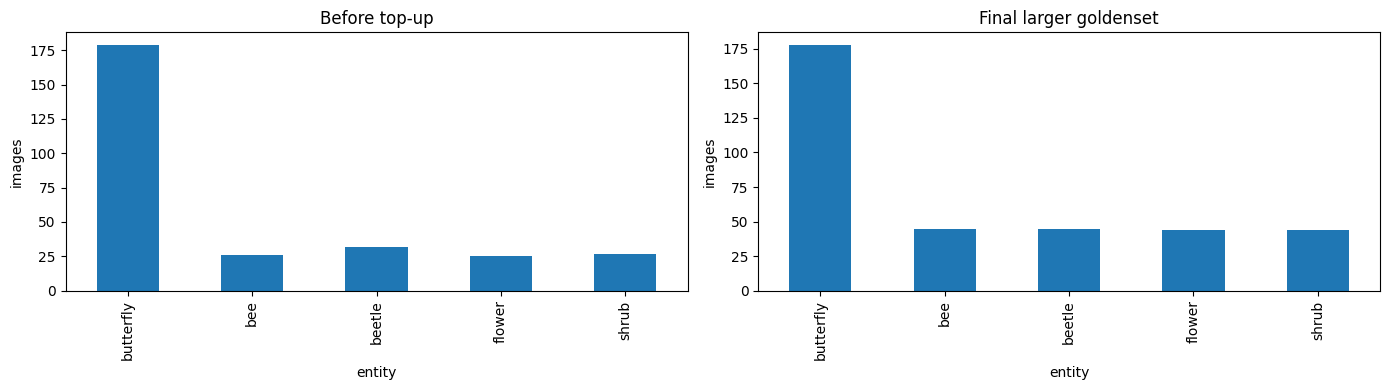

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

merged_df["entity"].value_counts().reindex(["butterfly", *negative_classes], fill_value=0).plot(
    kind="bar",
    ax=axes[0],
    title="Before top-up",
)
axes[0].set_ylabel("images")

larger_goldenset_df["entity"].value_counts().reindex(["butterfly", *negative_classes], fill_value=0).plot(
    kind="bar",
    ax=axes[1],
    title="Final larger goldenset",
)
axes[1].set_ylabel("images")

plt.tight_layout()
plt.show()


In [ ]:
REPO_ID = "vsevolod-nv/aiconf-butterfly-detection-goldenset-extended"

readme = f"""---
pretty_name: aiconf-butterfly-detection-goldenset-extended
task_categories:
- object-detection
- image-classification
tags:
- biology
- insects
- butterflies
- inaturalist
---

Extended goldenset for butterfly detection built from the original goldenset and a validated expansion pass.

Files:
- `larger_goldenset.json`
- `larger_goldenset.tsv`

Columns:
- `photo_id`
- `image`
- `entity`
- `bbox`

Generated at: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')}
Rows: {len(larger_goldenset_df)}
"""

api = HfApi()

with TemporaryDirectory() as tmp_dir:
    tmp_path = Path(tmp_dir)
    (tmp_path / "larger_goldenset.json").write_text(
        Path("larger_goldenset.json").read_text(encoding="utf-8"),
        encoding="utf-8",
    )
    (tmp_path / "larger_goldenset.tsv").write_text(
        Path("larger_goldenset.tsv").read_text(encoding="utf-8"),
        encoding="utf-8",
    )
    (tmp_path / "README.md").write_text(readme, encoding="utf-8")

    api.create_repo(repo_id=REPO_ID, repo_type="dataset", exist_ok=True)
    api.upload_folder(
        repo_id=REPO_ID,
        repo_type="dataset",
        folder_path=str(tmp_path),
        commit_message="Upload extended butterfly goldenset",
    )

REPO_ID
